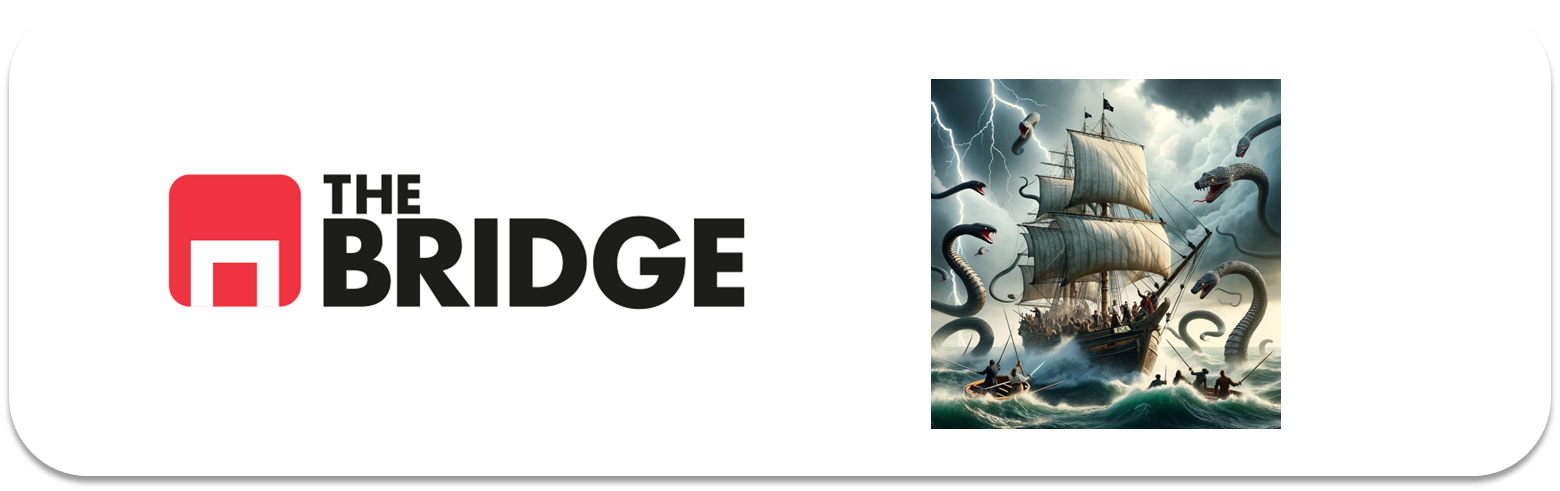

## PRACTICA OBLIGATORIA: **Seleccion Features**

* La práctica obligatoria de esta unidad consiste en hacer una comparativa de diferentes técnicas de selección de features sobre un dataset ya conocido. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Descripción General y Objetivo

El objetivo de la práctica es que juegues con las diferentes técncias de selección de features sobre un problema de clasificación. Para ello, tendrás que cargar el dataset de credit scoring que tienes en la carpeta "data" y que ya hemos trabajado anteriormente. A partir de ahí tendrás que probar diferentes técnicas de selección de features y compararlas todas entre sí y escoger finalmente el conjunto más sencillo con más potencia. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Detalles e Instrucciones

El objetivo es que construyas un modelo final de clasificació sobre la variable "SeriousDlqin2yrs" del dataset que encontrarás en "data".  

Sigue los pasos del proceso de ML que hemos aprendido para problemas supervisados con el dataset que encontrarás en "data" pero con las siguiente salvedades:

1. Deshazte de las filas con nulos, para este ejercicio no nos importan. Convierte las features NumberOf... que creas conveniente a categóricas con 2 o 3 niveles a lo sumo.

2. A la hora de hacer el miniEda aplica los siguientes análisis y selección de features: 
    1. Análisis visual combinado con filtrado por valores de correlación y umbral de covarianza.
    2. Selección de features numéricas mediante SelectKBest y ANOVA, selecció de features categóricas mediante Mutual Information 
    3. Selección de las mejores features a través de un modelo intermedio (usando SelectFromModel)
    4. Selección de las mejores features empleando RFE.
    5. Selección de las mejores features empleando SFS.
    6. Selección de las mejores features mediante un sistema de hard-voting aplicado a lo obtenido en los pasos 1 a 5 anteriores.

    Para cada paso anterior (salvo el 1) se pide obtener una lista de features de "primera división" con un número de variables no superior a 6 (pueden ser menos).

3. Escoge tres modelos y a la hora compararlos para escoger el mejor, entrenalos con validación cruzada empleando las seis listas obtenidas anteriormente. Es decir tendrás 18 (6*3) medidas (emplea la métrica que creas más conveniente y si no se te ocurre ninguna el recall medio).  Escoge el mejor modelo y la mejor selección de features.

4. Optimiza los hiperparámetros del mejor modelo. Evalúalo contra test.


In [2]:
df = pd.read_csv("./data/credit_npo.csv")

In [3]:
# eliminar nulos
df = df.dropna()

In [4]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0


In [5]:
def categorize_delays(x):
    if x == 0:
        return 0
    elif x == 1:
        return 1
    else:
        return 2

In [6]:
delay_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate"
]

for col in delay_cols:
    df[col] = df[col].apply(categorize_delays)

In [7]:
X = df.drop("SeriousDlqin2yrs", axis=1)
y = df["SeriousDlqin2yrs"]

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [9]:
cat_features = delay_cols
num_features = X.columns.difference(cat_features)

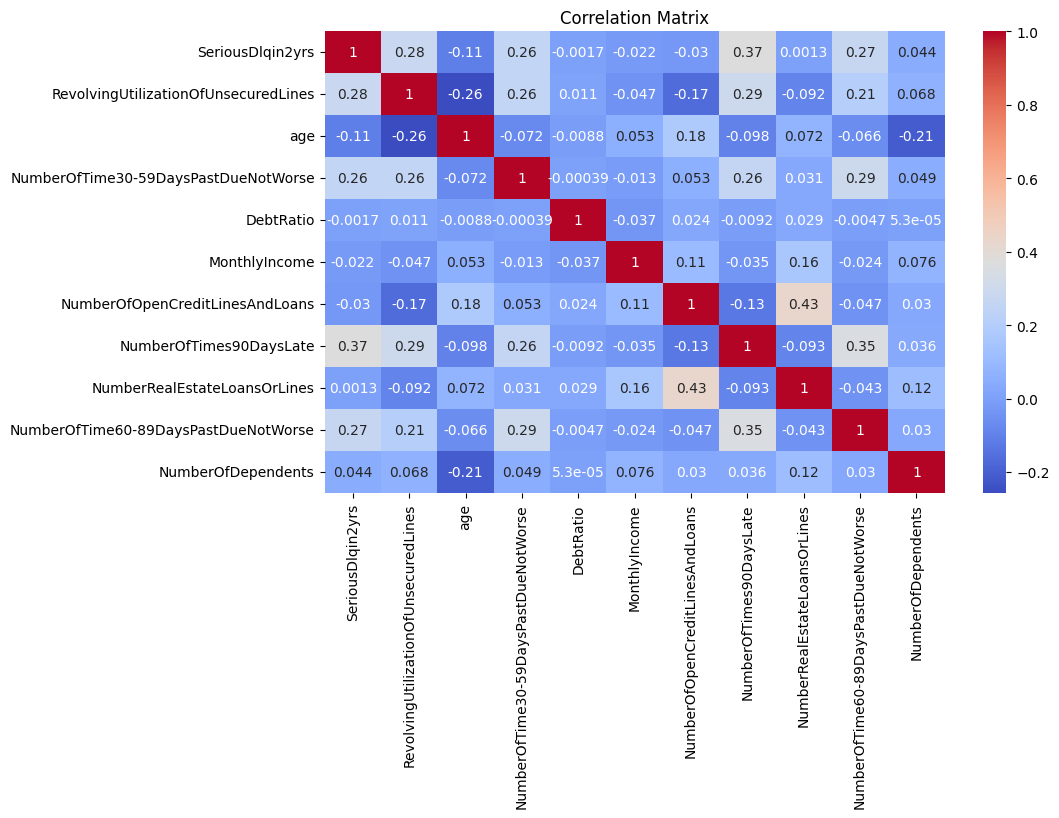

In [10]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

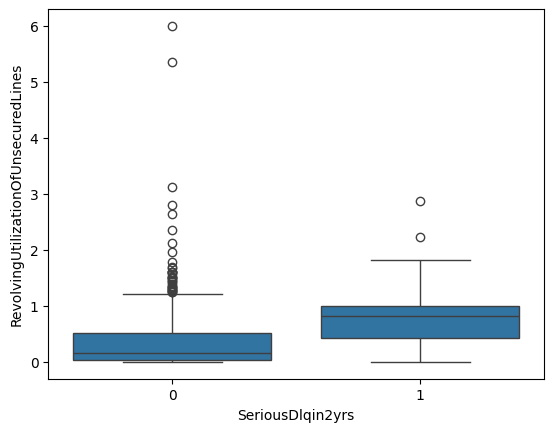

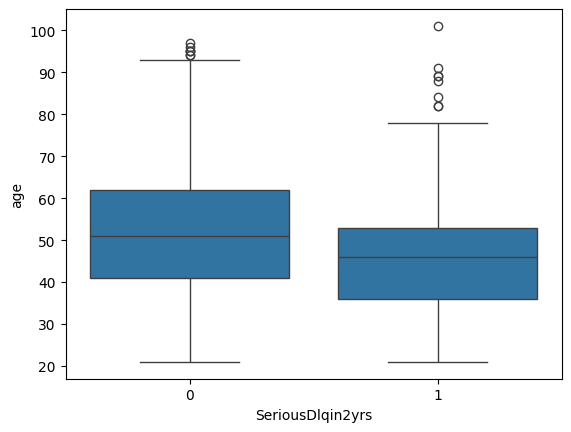

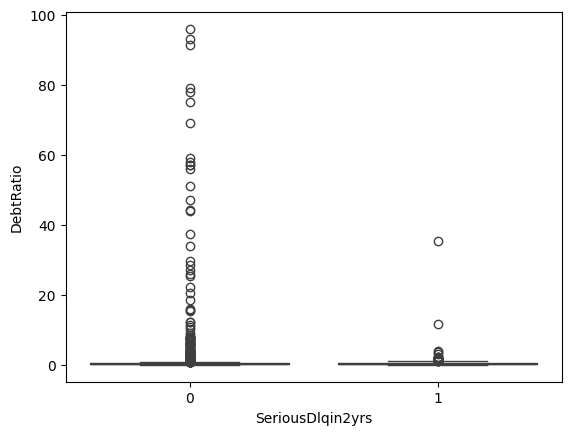

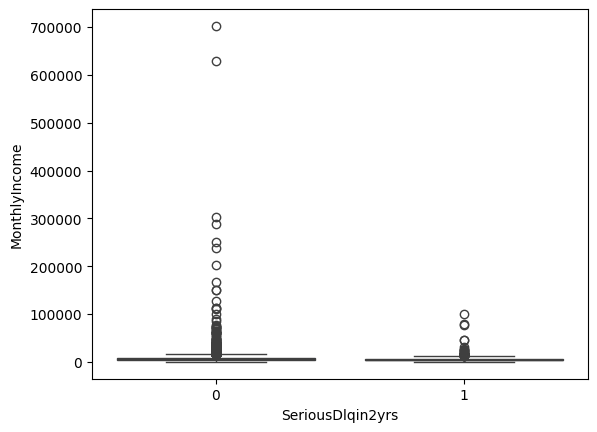

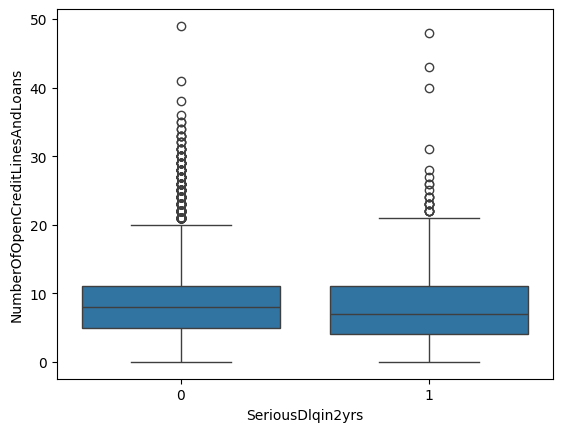

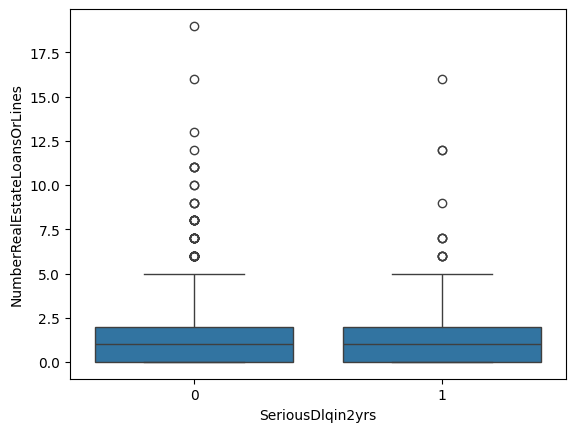

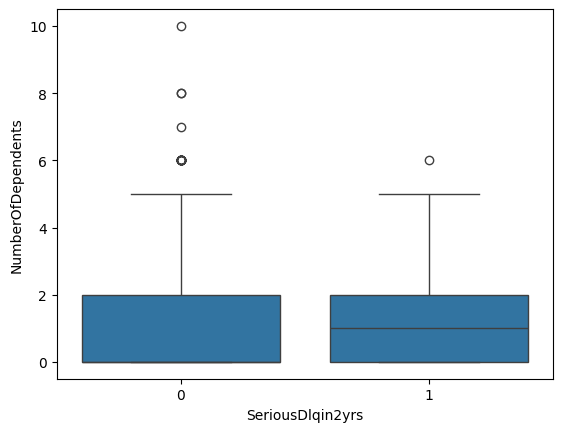

In [11]:
num_features = [
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberRealEstateLoansOrLines",
    "NumberOfDependents"
]

for col in num_features:
    sns.boxplot(x="SeriousDlqin2yrs", y=col, data=df)
    plt.show()

In [12]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)

selector.fit(X_train)

selected_variance = X_train.columns[selector.get_support()]

print(selected_variance)

Index(['RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')


In [13]:
feature_list_1 = [
    "NumberOfTimes90DaysLate",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "DebtRatio",
    "MonthlyIncome"
]

In [14]:
cat_features = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate"
]

num_features = [col for col in X_train.columns if col not in cat_features]

In [15]:
from sklearn.feature_selection import SelectKBest, f_classif

anova_selector = SelectKBest(score_func=f_classif, k=4)

anova_selector.fit(X_train[num_features], y_train)

anova_features = X_train[num_features].columns[anova_selector.get_support()]

print("Selected numeric features:", list(anova_features))

Selected numeric features: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfDependents']


In [16]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(
    X_train[cat_features],
    y_train,
    discrete_features=True
)

mi_scores = pd.Series(mi_scores, index=cat_features)
mi_scores = mi_scores.sort_values(ascending=False)

print(mi_scores)

NumberOfTimes90DaysLate                 0.035594
NumberOfTime30-59DaysPastDueNotWorse    0.023412
NumberOfTime60-89DaysPastDueNotWorse    0.020504
dtype: float64


In [17]:
mi_features = mi_scores.index[:2]

print("Selected categorical features:", list(mi_features))

Selected categorical features: ['NumberOfTimes90DaysLate', 'NumberOfTime30-59DaysPastDueNotWorse']


In [18]:
feature_list_2 = list(anova_features) + list(mi_features)

print("Feature List 2:", feature_list_2)

Feature List 2: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfDependents', 'NumberOfTimes90DaysLate', 'NumberOfTime30-59DaysPastDueNotWorse']


In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

selector = SelectFromModel(
    rf_model,
    max_features=6,
    threshold=-np.inf
)

selector.fit(X_train, y_train)

feature_list_3 = list(X_train.columns[selector.get_support()])

print("Feature List 3 (SelectFromModel):")
print(feature_list_3)

Feature List 3 (SelectFromModel):
['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate']


In [20]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=2000)

rfe = RFE(
    estimator=log_model,
    n_features_to_select=6
)

rfe.fit(X_train, y_train)

feature_list_4 = list(X_train.columns[rfe.support_])

print("Feature List 4 (RFE):")
print(feature_list_4)

Feature List 4 (RFE):
['RevolvingUtilizationOfUnsecuredLines', 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


In [21]:
from sklearn.feature_selection import SequentialFeatureSelector

sfs = SequentialFeatureSelector(
    log_model,
    n_features_to_select=6,
    direction="forward",
    scoring="recall",
    cv=5,
    n_jobs=-1
)

sfs.fit(X_train, y_train)

feature_list_5 = list(X_train.columns[sfs.get_support()])

print("Feature List 5 (SFS):")
print(feature_list_5)

Feature List 5 (SFS):
['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse']


In [22]:
from collections import Counter

all_features = (
    feature_list_1
    + feature_list_2
    + feature_list_3
    + feature_list_4
    + feature_list_5
)

feature_votes = Counter(all_features)

print(feature_votes)

Counter({'NumberOfTimes90DaysLate': 5, 'RevolvingUtilizationOfUnsecuredLines': 5, 'NumberOfTime30-59DaysPastDueNotWorse': 3, 'age': 3, 'DebtRatio': 3, 'NumberOfOpenCreditLinesAndLoans': 3, 'MonthlyIncome': 2, 'NumberOfDependents': 2, 'NumberRealEstateLoansOrLines': 2, 'NumberOfTime60-89DaysPastDueNotWorse': 2})


In [23]:
feature_list_6 = [
    feature for feature, count
    in feature_votes.most_common(6)
]

print("Feature List 6 (Hard Voting):")
print(feature_list_6)

Feature List 6 (Hard Voting):
['NumberOfTimes90DaysLate', 'RevolvingUtilizationOfUnsecuredLines', 'NumberOfTime30-59DaysPastDueNotWorse', 'age', 'DebtRatio', 'NumberOfOpenCreditLinesAndLoans']


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42)
}

In [25]:
feature_sets = {
    "visual_corr": feature_list_1,
    "anova_mi": feature_list_2,
    "selectfrommodel": feature_list_3,
    "rfe": feature_list_4,
    "sfs": feature_list_5,
    "hard_voting": feature_list_6
}

In [26]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [27]:
from sklearn.model_selection import cross_val_score
import pandas as pd

results = []

for model_name, model in models.items():

    for feature_set_name, features in feature_sets.items():

        X_subset = X_train[features]

        scores = cross_val_score(
            model,
            X_subset,
            y_train,
            cv=cv,
            scoring="recall",
            n_jobs=-1
        )

        results.append({
            "model": model_name,
            "feature_set": feature_set_name,
            "mean_recall": scores.mean(),
            "std": scores.std()
        })

results_df = pd.DataFrame(results)

In [28]:
results_df = results_df.sort_values(
    by="mean_recall",
    ascending=False
)

print(results_df)

                 model      feature_set  mean_recall       std
9         RandomForest              rfe     0.241057  0.039058
16    GradientBoosting              sfs     0.223001  0.039043
15    GradientBoosting              rfe     0.222978  0.037955
6         RandomForest      visual_corr     0.219970  0.031764
12    GradientBoosting      visual_corr     0.213921  0.025194
13    GradientBoosting         anova_mi     0.212383  0.011725
11        RandomForest      hard_voting     0.206380  0.025045
17    GradientBoosting      hard_voting     0.204876  0.024520
10        RandomForest              sfs     0.203440  0.044912
7         RandomForest         anova_mi     0.201846  0.019109
8         RandomForest  selectfrommodel     0.200387  0.033804
4   LogisticRegression              sfs     0.200387  0.031013
14    GradientBoosting  selectfrommodel     0.200365  0.031876
3   LogisticRegression              rfe     0.191342  0.028620
5   LogisticRegression      hard_voting     0.186831  0

In [29]:
best_row = results_df.iloc[0]

best_model_name = best_row["model"]
best_feature_set_name = best_row["feature_set"]

best_features = feature_sets[best_feature_set_name]

print("Best Model:", best_model_name)
print("Best Feature Set:", best_feature_set_name)
print("Best Features:", best_features)

Best Model: RandomForest
Best Feature Set: rfe
Best Features: ['RevolvingUtilizationOfUnsecuredLines', 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


In [30]:
best_model = models[best_model_name]

In [31]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=2000),
    param_grid,
    cv=cv,
    scoring="recall",
    n_jobs=-1
)

grid.fit(X_train[best_features], y_train)

best_model = grid.best_estimator_

print(grid.best_params_)

{'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}


c:\Users\nicho\Documents\GitHub\ONLINE_DS_THEBRIDGE_repo_nicholas_brown\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\nicho\Documents\GitHub\ONLINE_DS_THEBRIDGE_repo_nicholas_brown\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [32]:
from sklearn.metrics import classification_report

best_model.fit(X_train[best_features], y_train)

y_pred = best_model.predict(X_test[best_features])

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.99      0.96      2198
           1       0.56      0.21      0.31       166

    accuracy                           0.93      2364
   macro avg       0.75      0.60      0.64      2364
weighted avg       0.92      0.93      0.92      2364



c:\Users\nicho\Documents\GitHub\ONLINE_DS_THEBRIDGE_repo_nicholas_brown\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\nicho\Documents\GitHub\ONLINE_DS_THEBRIDGE_repo_nicholas_brown\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


### EXTRA

Aplica la PCA como método de selección, escoge un número de componentes en función de la varianza explicada y crea un dataset con el que entrenar el mismo tipo de modelo ganador de la parte general. Entrenalo y evalúalo contra test, comenta el resultado.

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

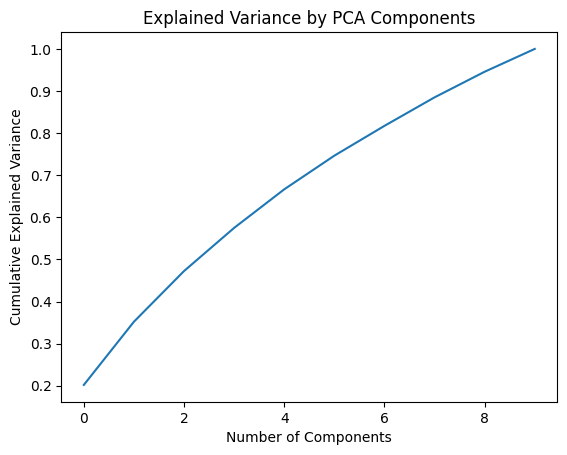

In [34]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_train_scaled)

explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.plot(explained_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA Components")
plt.show()

In [35]:
np.cumsum(pca.explained_variance_ratio_)

array([0.2019975 , 0.35211027, 0.47244649, 0.5749427 , 0.66651682,
       0.74645044, 0.81726228, 0.88493637, 0.94578879, 1.        ])

In [36]:
n_components = 7

In [37]:
pca = PCA(n_components=7)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [38]:
best_model.fit(X_train_pca, y_train)

c:\Users\nicho\Documents\GitHub\ONLINE_DS_THEBRIDGE_repo_nicholas_brown\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\nicho\Documents\GitHub\ONLINE_DS_THEBRIDGE_repo_nicholas_brown\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",10
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` 

In [39]:
from sklearn.metrics import classification_report

y_pred_pca = best_model.predict(X_test_pca)

print(classification_report(y_test, y_pred_pca))

              precision    recall  f1-score   support

           0       0.94      0.99      0.96      2198
           1       0.55      0.20      0.29       166

    accuracy                           0.93      2364
   macro avg       0.75      0.59      0.63      2364
weighted avg       0.91      0.93      0.92      2364

